,layer,language,overlap_ratio,spearman_corr,pearson_corr,mean_native,mean_roman,overlap_count
0,0,hi,0.12,-0.679522,-0.620746,0.019093,0.002620,12
1,0,sd,0.09,-0.726942,-0.696736,0.011948,0.004631,9
2,0,ur,0.09,-0.723854,-0.733325,0.013624,0.004022,9
3,0,bn,0.01,-0.850221,-0.684981,0.011997,0.003272,1
4,1,hi,0.06,-0.813605,-0.909620,0.021579,0.003139,6


[INFO] Saved summary to /home/aastha/multilingual_interpretability/identification/Llama-3.2-1B/magnitude/romanization_summary.csv


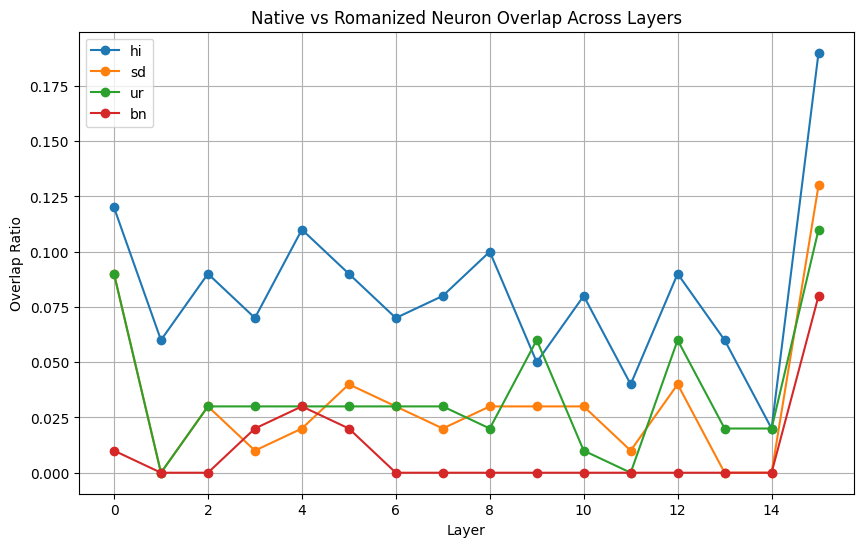

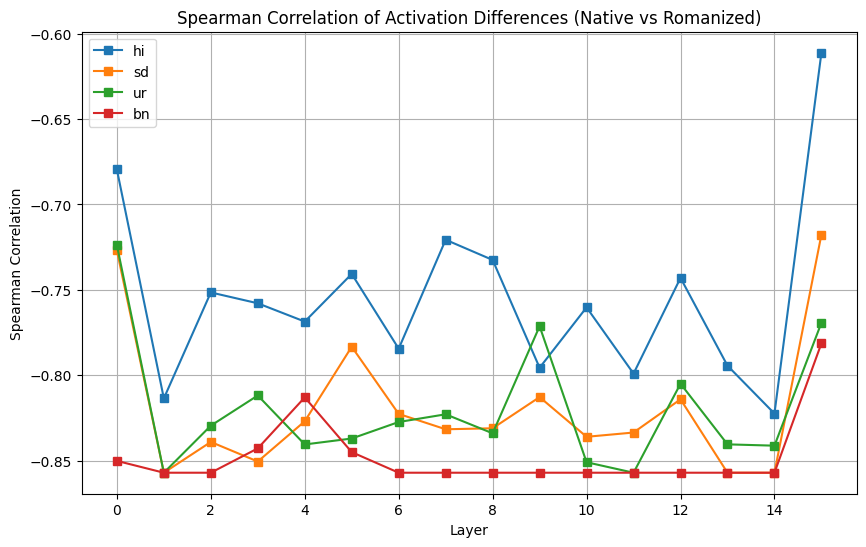

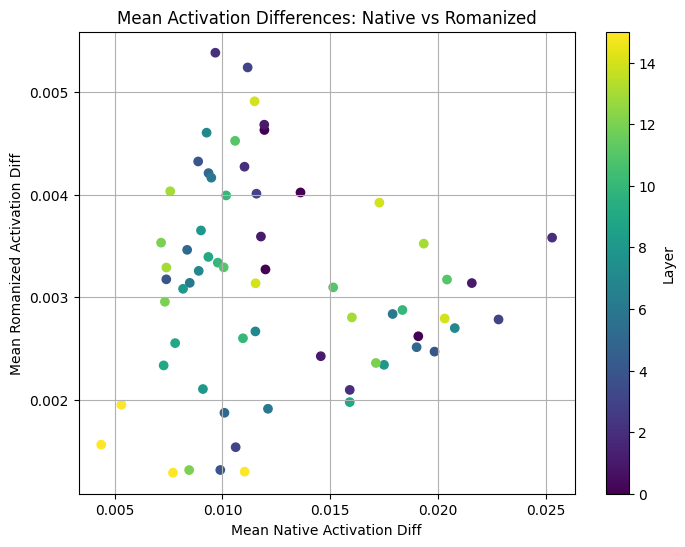

In [2]:
# --- Romanization Analysis for LLM Neuron Experiments ---

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import spearmanr, pearsonr

# === CONFIG ===
base_dir = "/home/aastha/multilingual_interpretability/identification/Llama-3.2-1B/magnitude"
experiment_root = "dakshina-{variant}-hi-sd-ur-bn/train"
languages = ["hi", "sd", "ur", "bn"]   # modify if needed
num_layers = 16                       # change according to your model
topk = 100

# === STORAGE ===
results = []

# === MAIN LOOP ===
for layer in range(num_layers):
    layer_dir = f"layer_{layer}"
    
    for lang in languages:
        # file paths
        native_path = Path(base_dir) / layer_dir / experiment_root.format(variant="native") / f"{lang}.csv"
        roman_path  = Path(base_dir) / layer_dir / experiment_root.format(variant="romanized") / f"{lang}.csv"

        if not native_path.exists() or not roman_path.exists():
            print(f"[WARN] Missing files for layer {layer}, language {lang}")
            continue

        # load csvs
        df_native = pd.read_csv(native_path)
        df_roman  = pd.read_csv(roman_path)

        # merge for correlation
        merged = pd.merge(df_native, df_roman, on="feature_idx", suffixes=("_native", "_roman"), how="outer").fillna(0)

        # overlap
        overlap = len(set(df_native.feature_idx) & set(df_roman.feature_idx))
        overlap_ratio = overlap / topk

        # correlations
        corr_spear, _ = spearmanr(merged["avg_activation_native"], merged["avg_activation_roman"])
        corr_pear, _  = pearsonr(merged["avg_activation_native"], merged["avg_activation_roman"])

        # activation stats
        mean_native = df_native["avg_activation"].mean()
        mean_roman  = df_roman["avg_activation"].mean()

        results.append({
            "layer": layer,
            "language": lang,
            "overlap_ratio": overlap_ratio,
            "spearman_corr": corr_spear,
            "pearson_corr": corr_pear,
            "mean_native": mean_native,
            "mean_roman": mean_roman,
            "overlap_count": overlap
        })

# === COMBINE RESULTS ===
df_summary = pd.DataFrame(results)
display(df_summary.head())

# === SAVE ===
out_path = Path(base_dir) / "romanization_summary.csv"
df_summary.to_csv(out_path, index=False)
print(f"[INFO] Saved summary to {out_path}")

# === VISUALIZATIONS ===

# 1. Overlap ratio per layer
plt.figure(figsize=(10,6))
for lang in languages:
    subset = df_summary[df_summary.language == lang]
    plt.plot(subset.layer, subset.overlap_ratio, marker='o', label=lang)
plt.title("Native vs Romanized Neuron Overlap Across Layers")
plt.xlabel("Layer")
plt.ylabel("Overlap Ratio")
plt.legend()
plt.grid(True)
plt.show()

# 2. Spearman correlation per layer
plt.figure(figsize=(10,6))
for lang in languages:
    subset = df_summary[df_summary.language == lang]
    plt.plot(subset.layer, subset.spearman_corr, marker='s', label=lang)
plt.title("Spearman Correlation of Activation Differences (Native vs Romanized)")
plt.xlabel("Layer")
plt.ylabel("Spearman Correlation")
plt.legend()
plt.grid(True)
plt.show()

# 3. Average activation magnitude comparison
plt.figure(figsize=(8,6))
plt.scatter(df_summary.mean_native, df_summary.mean_roman, c=df_summary.layer, cmap="viridis")
plt.colorbar(label="Layer")
plt.title("Mean Activation Differences: Native vs Romanized")
plt.xlabel("Mean Native Activation Diff")
plt.ylabel("Mean Romanized Activation Diff")
plt.grid(True)
plt.show()


,variant,layer,num_unique_neurons,num_highly_selective,num_shared,mean_langs_per_neuron
0,native,0,354,309,45,1.129944
1,native,1,376,352,24,1.063830
2,native,2,368,336,32,1.086957
3,native,3,369,338,31,1.084011
4,native,4,360,320,40,1.111111


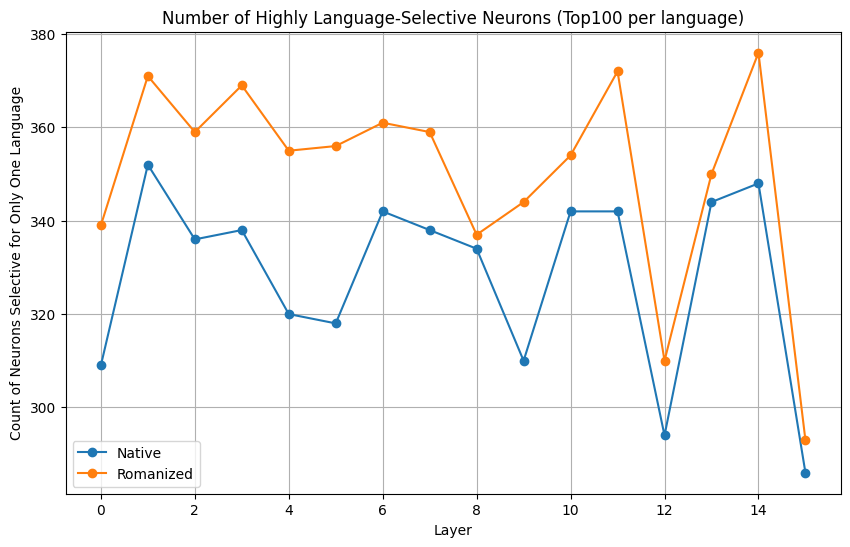

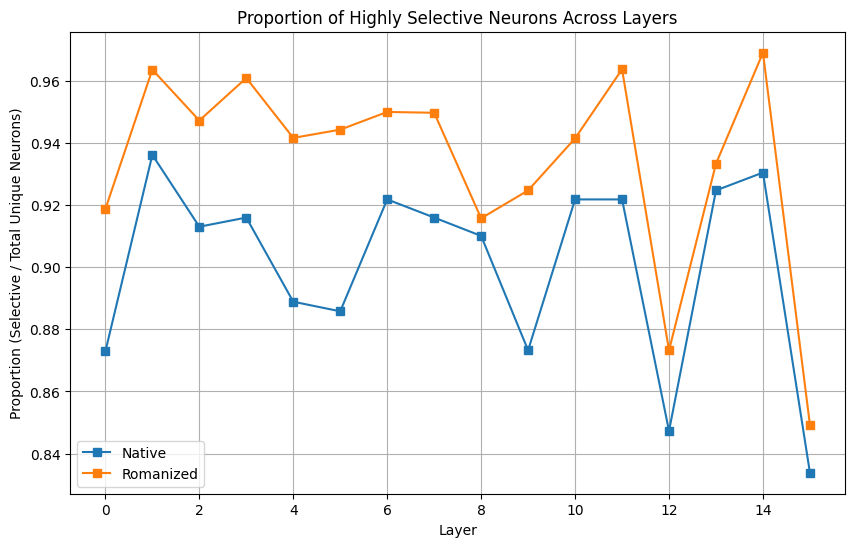

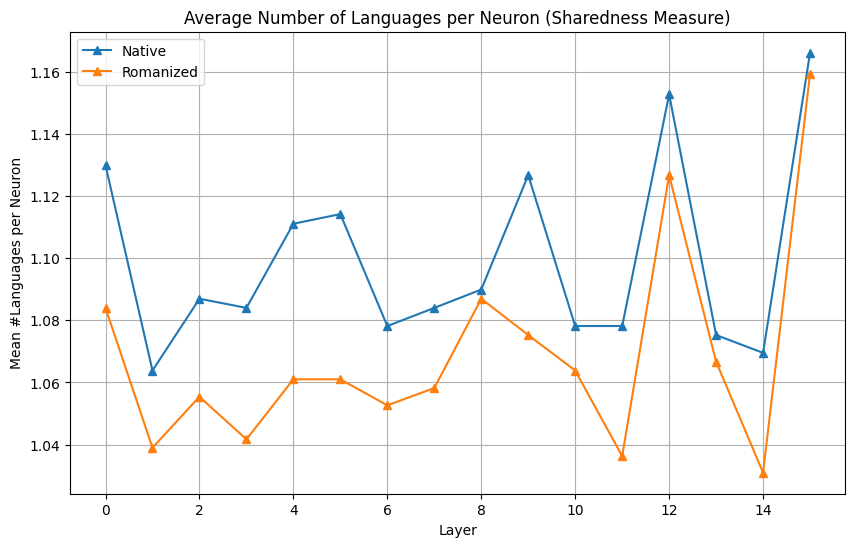

In [ ]:
# --- High Selectivity Neuron Count Analysis (Across Layers) ---

import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# === CONFIG ===
base_dir = "/home/aastha/multilingual_interpretability/identification/Llama-3.2-1B/magnitude"
experiment_root = "dakshina-{variant}-hi-sd-ur-bn/train"
languages = ["hi", "sd", "ur", "bn"]
num_layers = 16
topk = 100

results_selectivity = []

for variant in ["native", "romanized"]:
    for layer in range(num_layers):
        layer_dir = f"layer_{layer}"
        neuron_lang_counter = Counter()

        # collect all top neurons for all languages
        for lang in languages:
            fpath = Path(base_dir) / layer_dir / experiment_root.format(variant=variant) / f"{lang}.csv"
            if not fpath.exists():
                continue
            df = pd.read_csv(fpath)
            for n in df["feature_idx"].astype(int).tolist():
                neuron_lang_counter[n] += 1

        # convert counter → dataframe
        if not neuron_lang_counter:
            continue
        df_counts = pd.DataFrame(list(neuron_lang_counter.items()), columns=["feature_idx", "count"])
        df_counts["layer"] = layer
        df_counts["variant"] = variant

        # statistics
        num_total = len(df_counts)
        num_highly_selective = (df_counts["count"] == 1).sum()  # neurons active for only one language
        num_shared = (df_counts["count"] > 1).sum()
        mean_count = df_counts["count"].mean()

        results_selectivity.append({
            "variant": variant,
            "layer": layer,
            "num_unique_neurons": num_total,
            "num_highly_selective": num_highly_selective,
            "num_shared": num_shared,
            "mean_langs_per_neuron": mean_count
        })

# Combine results
df_sel = pd.DataFrame(results_selectivity)
display(df_sel.head())

# === Highly Selective Neuron Counts Across Layers ===
plt.figure(figsize=(10,6))
for variant, color in zip(["native", "romanized"], ["C0", "C1"]):
    subset = df_sel[df_sel.variant == variant]
    plt.plot(subset.layer, subset.num_highly_selective, marker='o', label=f"{variant.capitalize()}")
plt.title("Number of Highly Language-Selective Neurons (Top100 per language)")
plt.xlabel("Layer")
plt.ylabel("Count of Neurons Selective for Only One Language")
plt.legend()
plt.grid(True)
plt.show()

# === Proportion of Selective vs Shared ===
plt.figure(figsize=(10,6))
for variant, color in zip(["native", "romanized"], ["C2", "C3"]):
    subset = df_sel[df_sel.variant == variant]
    prop_selective = subset.num_highly_selective / subset.num_unique_neurons
    plt.plot(subset.layer, prop_selective, marker='s', label=f"{variant.capitalize()}")
plt.title("Proportion of Highly Selective Neurons Across Layers")
plt.xlabel("Layer")
plt.ylabel("Proportion (Selective / Total Unique Neurons)")
plt.legend()
plt.grid(True)
plt.show()

# === Plot 3️⃣: Mean Languages per Neuron ===
plt.figure(figsize=(10,6))
for variant, color in zip(["native", "romanized"], ["C4", "C5"]):
    subset = df_sel[df_sel.variant == variant]
    plt.plot(subset.layer, subset.mean_langs_per_neuron, marker='^', label=f"{variant.capitalize()}")
plt.title("Average Number of Languages per Neuron (Sharedness Measure)")
plt.xlabel("Layer")
plt.ylabel("Mean #Languages per Neuron")
plt.legend()
plt.grid(True)
plt.show()


,layer,overlap_mean,overlap_std,spearman_mean,spearman_std,pearson_mean,pearson_std,mean_native,mean_roman
0,0,0.0775,0.047170,-0.745135,0.073330,-0.683947,0.046894,0.014166,0.003636
1,1,0.0150,0.030000,-0.846268,0.021775,-0.908941,0.051210,0.014969,0.003460
2,2,0.0375,0.037749,-0.819355,0.046629,-0.881062,0.042510,0.015478,0.003834
3,3,0.0325,0.026300,-0.815822,0.042082,-0.870664,0.084349,0.014046,0.003393
4,4,0.0475,0.041932,-0.812313,0.031230,-0.806518,0.129534,0.011503,0.002822


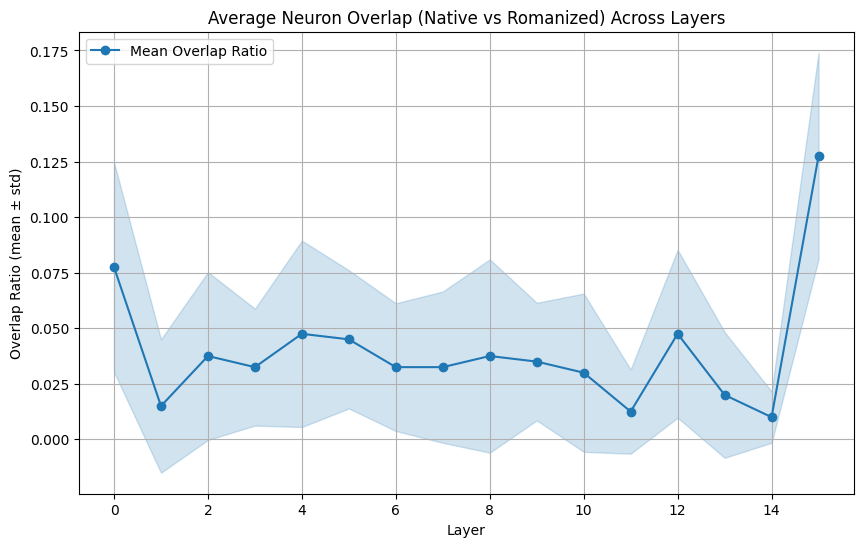

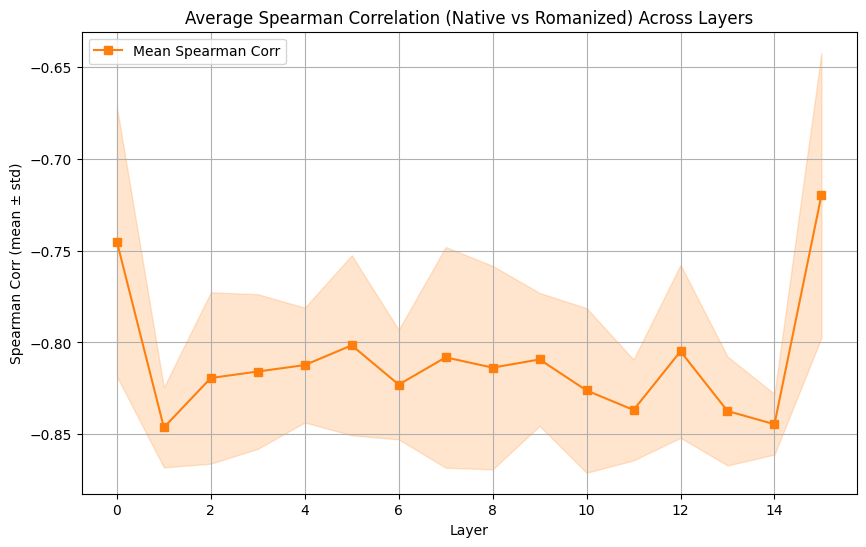

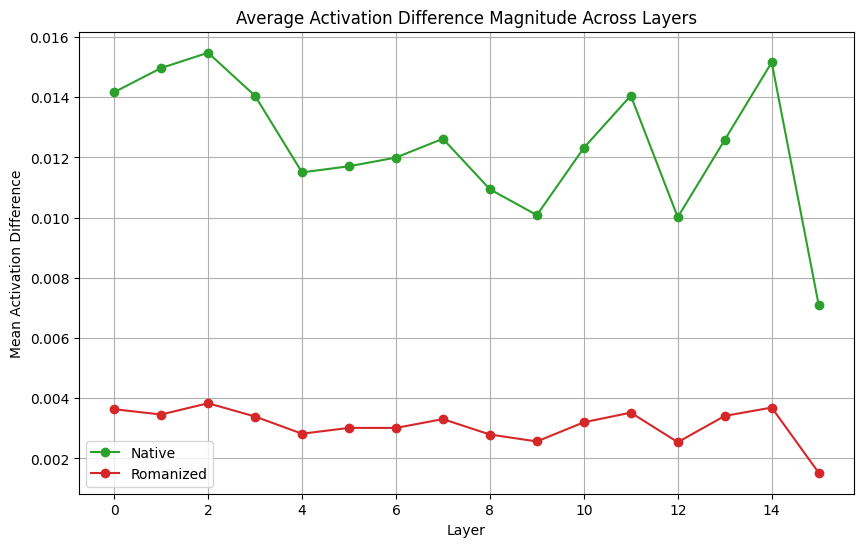

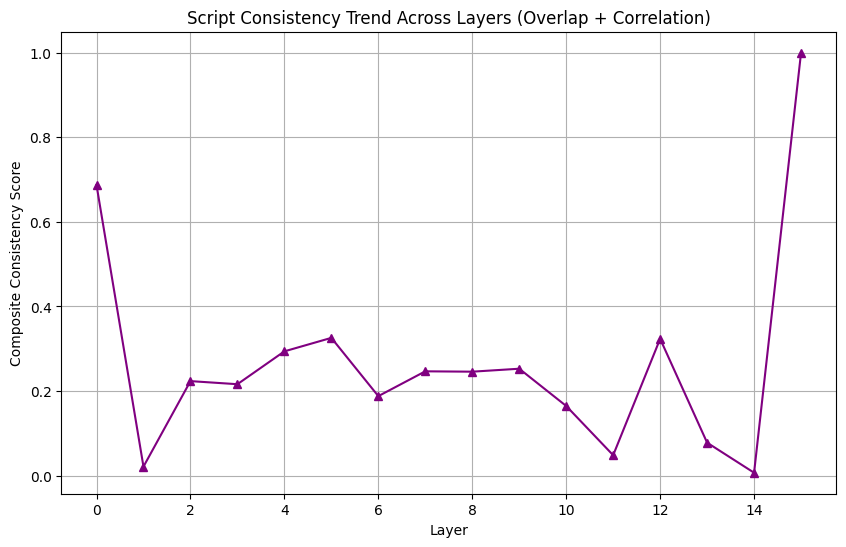

In [8]:
# --- Layerwise Trend Analysis: Romanization Effects Across Layers ---

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# === CONFIG ===
base_dir = "/home/aastha/multilingual_interpretability/identification/Llama-3.2-1B/magnitude"
summary_path = Path(base_dir) / "romanization_summary.csv"

# Load the summary if not already in memory
if "df_summary" not in locals():
    df_summary = pd.read_csv(summary_path)

# === AGGREGATION ===
# Compute mean & std across languages for each layer
df_layer = (
    df_summary.groupby("layer")
    .agg({
        "overlap_ratio": ["mean", "std"],
        "spearman_corr": ["mean", "std"],
        "pearson_corr": ["mean", "std"],
        "mean_native": "mean",
        "mean_roman": "mean"
    })
    .reset_index()
)

# Flatten column names
df_layer.columns = ["layer", "overlap_mean", "overlap_std", 
                    "spearman_mean", "spearman_std", 
                    "pearson_mean", "pearson_std",
                    "mean_native", "mean_roman"]

display(df_layer.head())

# === 1️⃣ Overlap Ratio Trend ===
plt.figure(figsize=(10,6))
plt.plot(df_layer.layer, df_layer.overlap_mean, marker='o', label="Mean Overlap Ratio", color="C0")
plt.fill_between(df_layer.layer,
                 df_layer.overlap_mean - df_layer.overlap_std,
                 df_layer.overlap_mean + df_layer.overlap_std,
                 color="C0", alpha=0.2)
plt.title("Average Neuron Overlap (Native vs Romanized) Across Layers")
plt.xlabel("Layer")
plt.ylabel("Overlap Ratio (mean ± std)")
plt.grid(True)
plt.legend()
plt.show()

# === 2️⃣ Spearman Correlation Trend ===
plt.figure(figsize=(10,6))
plt.plot(df_layer.layer, df_layer.spearman_mean, marker='s', label="Mean Spearman Corr", color="C1")
plt.fill_between(df_layer.layer,
                 df_layer.spearman_mean - df_layer.spearman_std,
                 df_layer.spearman_mean + df_layer.spearman_std,
                 color="C1", alpha=0.2)
plt.title("Average Spearman Correlation (Native vs Romanized) Across Layers")
plt.xlabel("Layer")
plt.ylabel("Spearman Corr (mean ± std)")
plt.grid(True)
plt.legend()
plt.show()

# === 3️⃣ Mean Activation Differences ===
plt.figure(figsize=(10,6))
plt.plot(df_layer.layer, df_layer.mean_native, marker='o', label="Native", color="C2")
plt.plot(df_layer.layer, df_layer.mean_roman, marker='o', label="Romanized", color="C3")
plt.title("Average Activation Difference Magnitude Across Layers")
plt.xlabel("Layer")
plt.ylabel("Mean Activation Difference")
plt.legend()
plt.grid(True)
plt.show()

# === 4️⃣ Combined Trend Summary (Optional Composite Metric) ===
# Define a simple "script-consistency" metric = average of normalized overlap + correlation
overlap_norm = (df_layer.overlap_mean - df_layer.overlap_mean.min()) / (df_layer.overlap_mean.max() - df_layer.overlap_mean.min())
corr_norm = (df_layer.spearman_mean - df_layer.spearman_mean.min()) / (df_layer.spearman_mean.max() - df_layer.spearman_mean.min())
df_layer["script_consistency"] = 0.5 * (overlap_norm + corr_norm)

plt.figure(figsize=(10,6))
plt.plot(df_layer.layer, df_layer.script_consistency, marker='^', color="purple")
plt.title("Script Consistency Trend Across Layers (Overlap + Correlation)")
plt.xlabel("Layer")
plt.ylabel("Composite Consistency Score")
plt.grid(True)
plt.show()


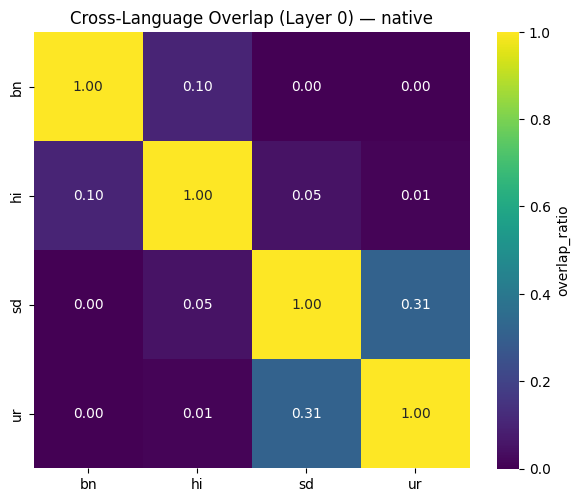

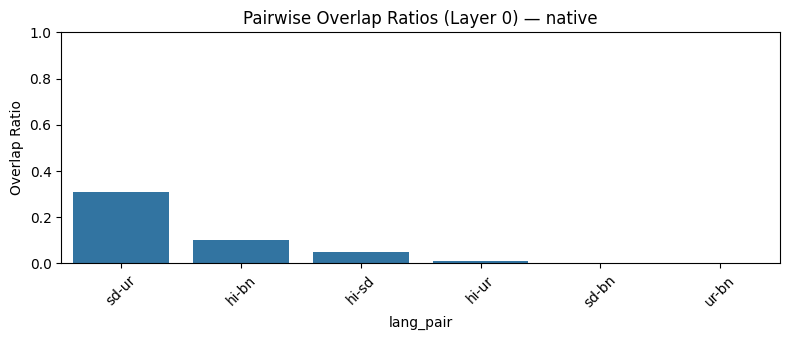

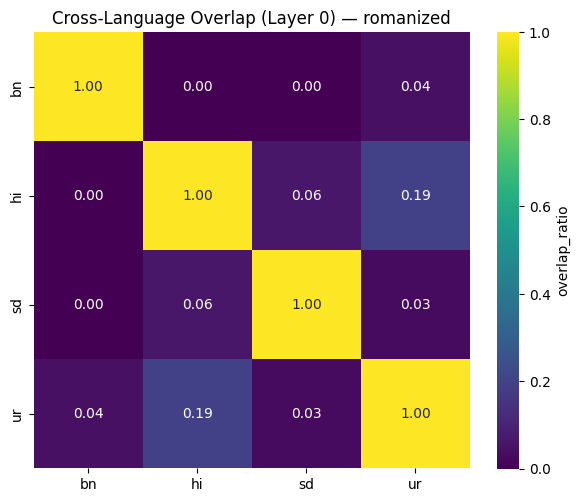

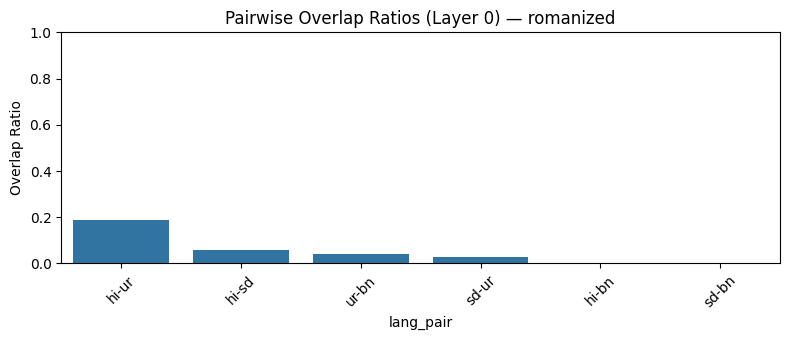

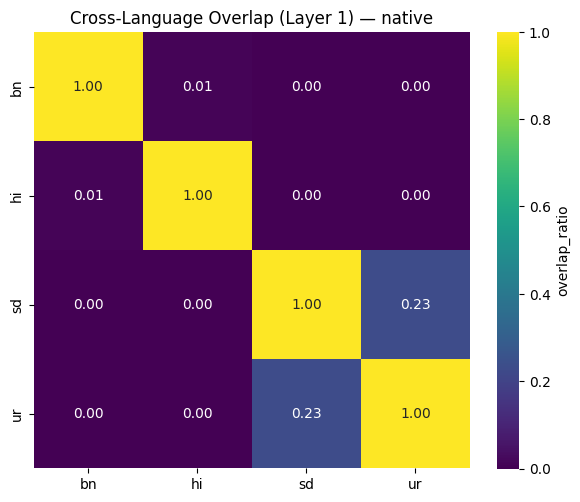

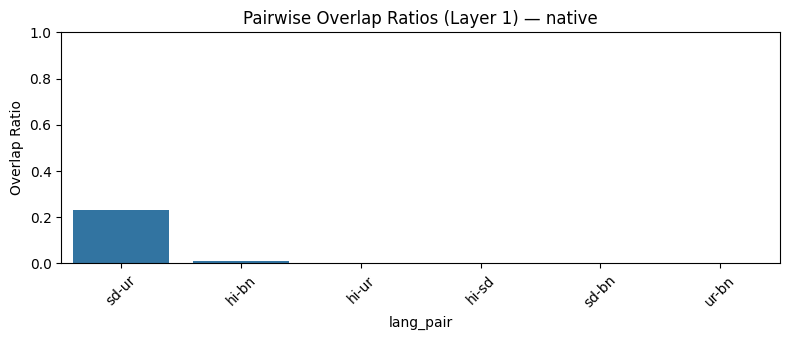

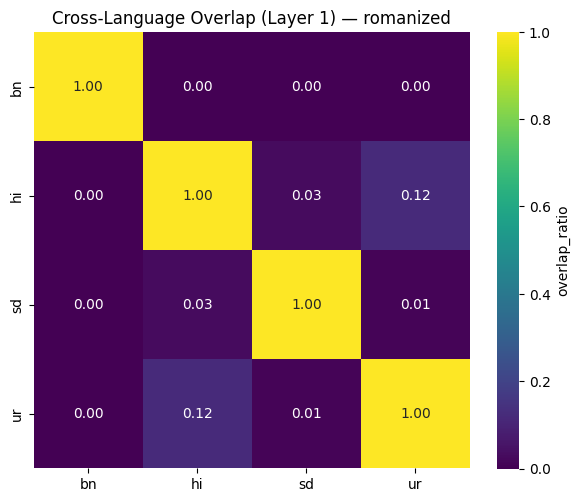

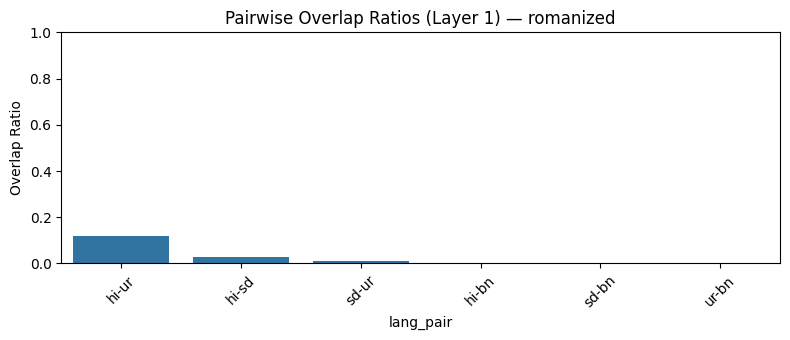

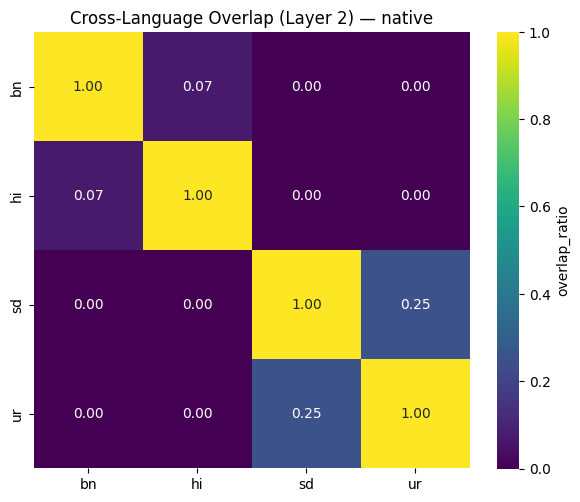

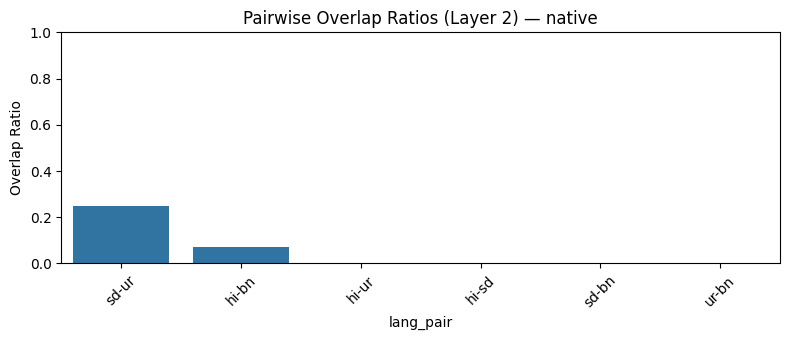

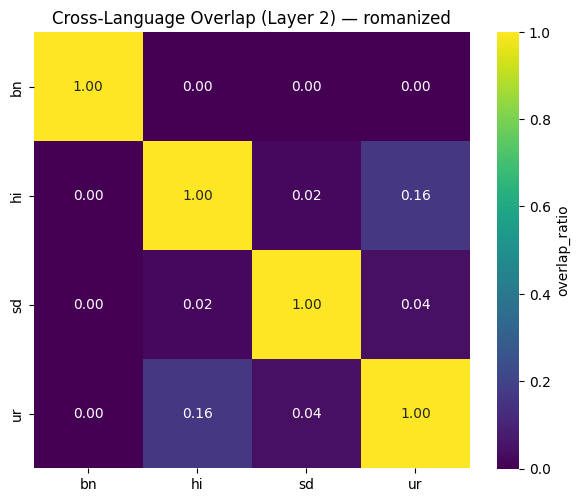

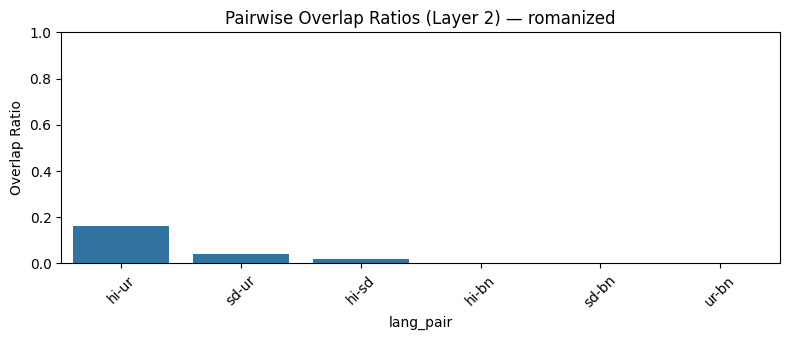

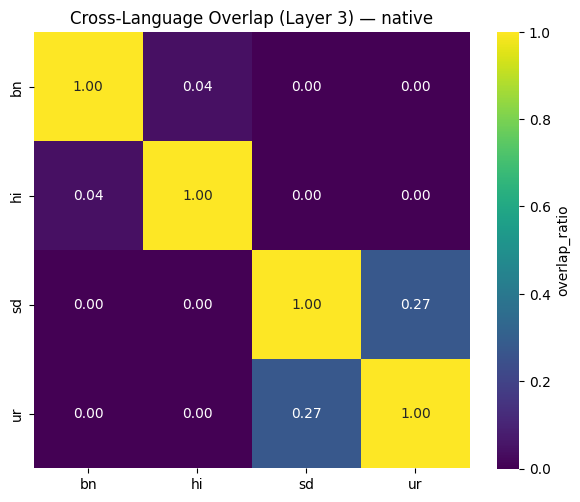

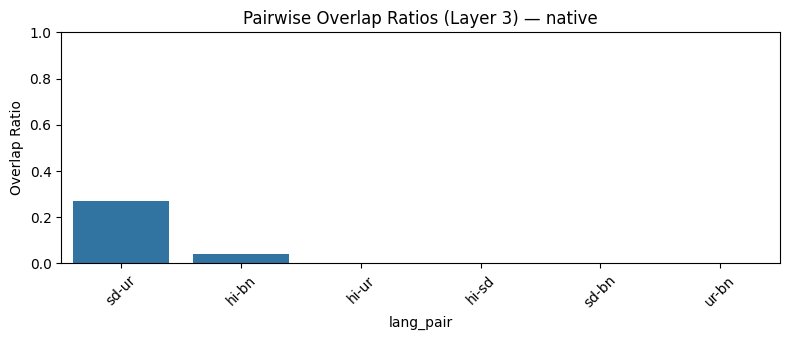

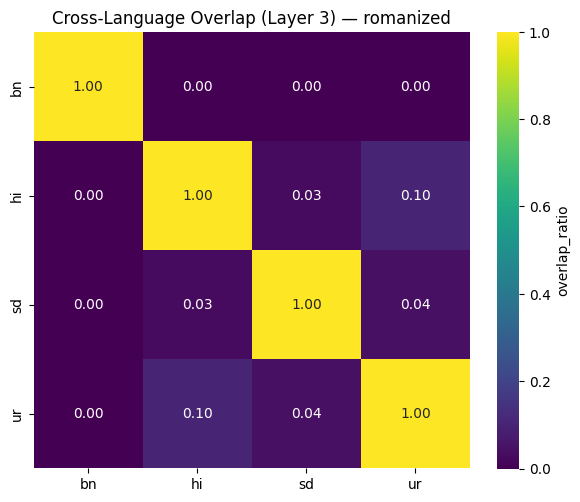

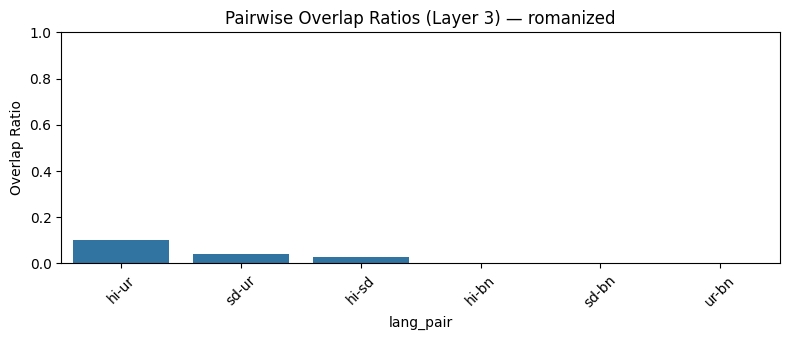

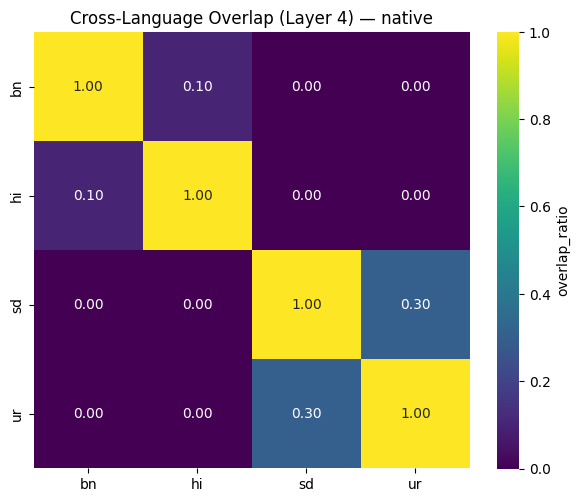

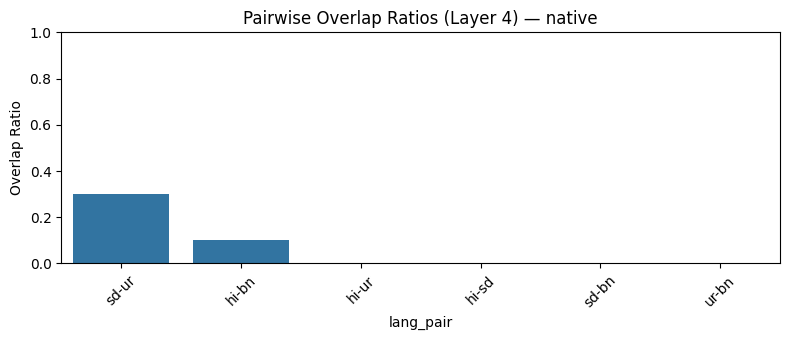

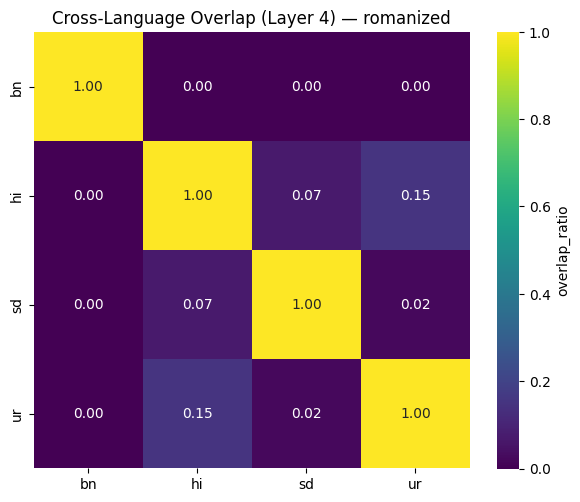

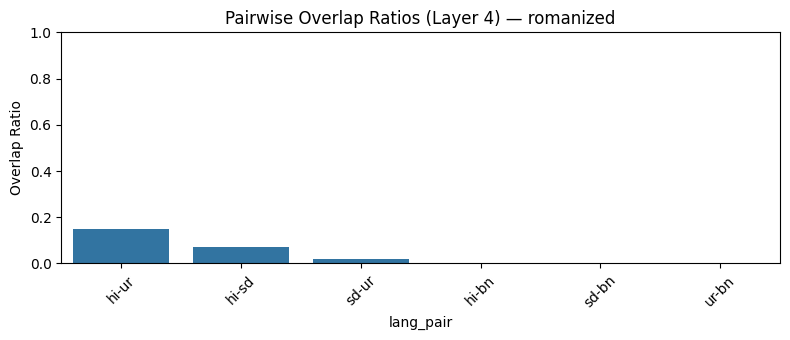

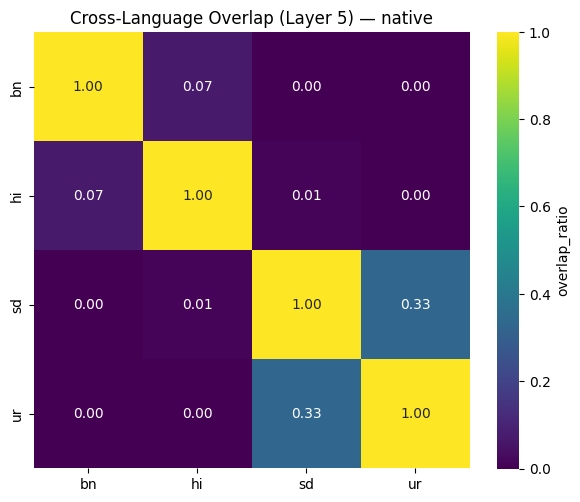

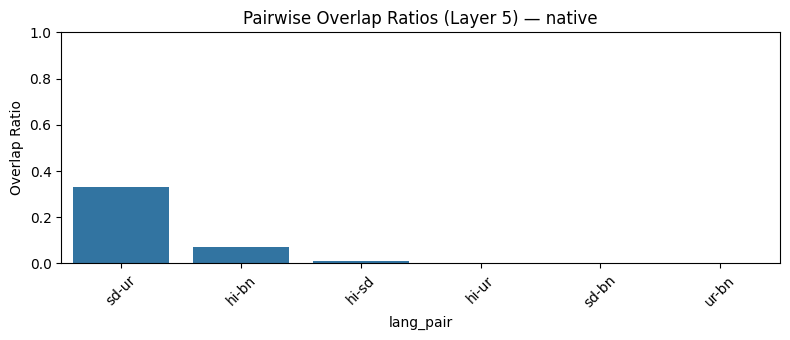

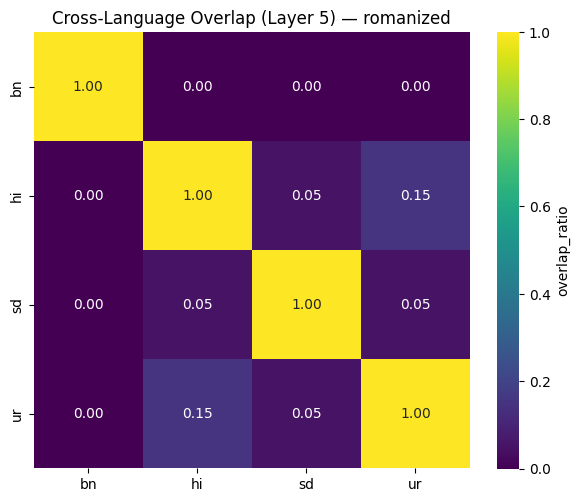

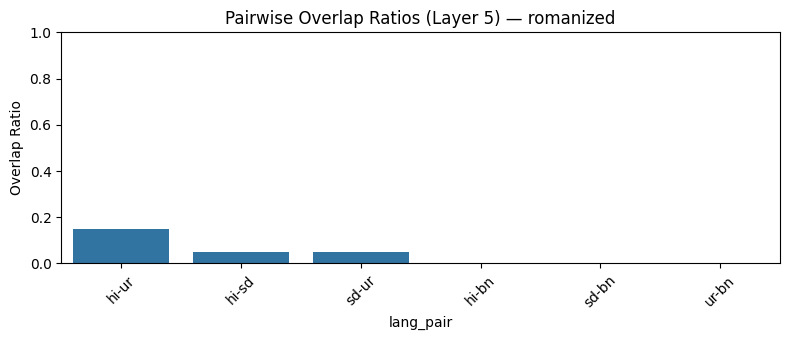

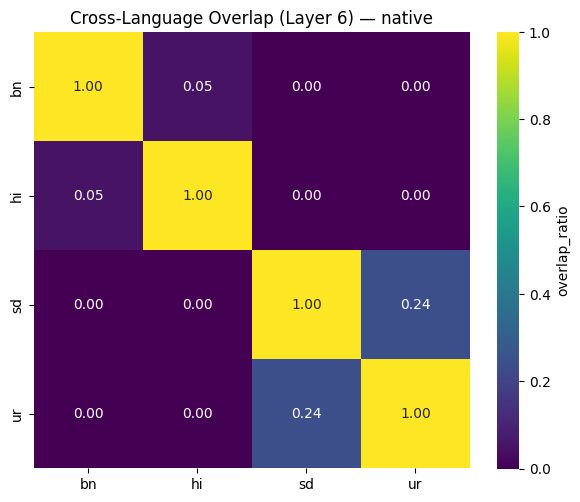

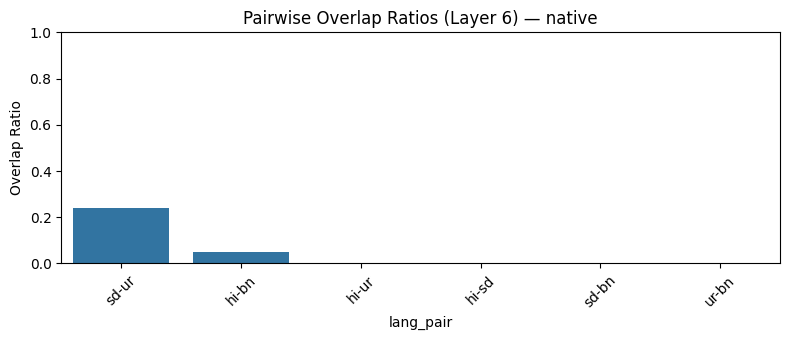

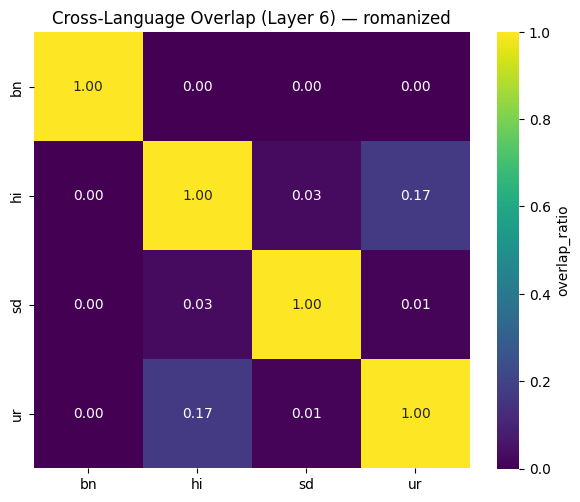

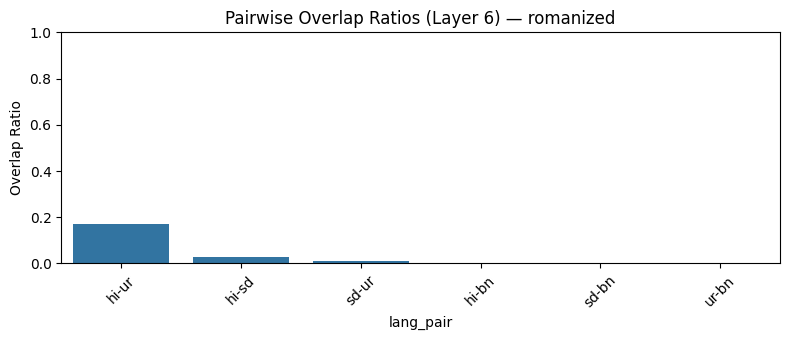

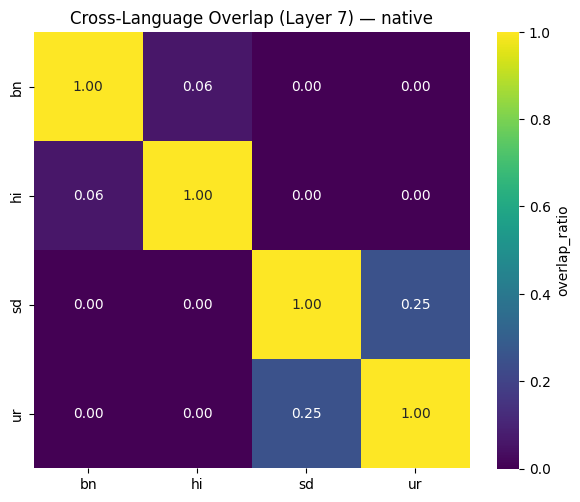

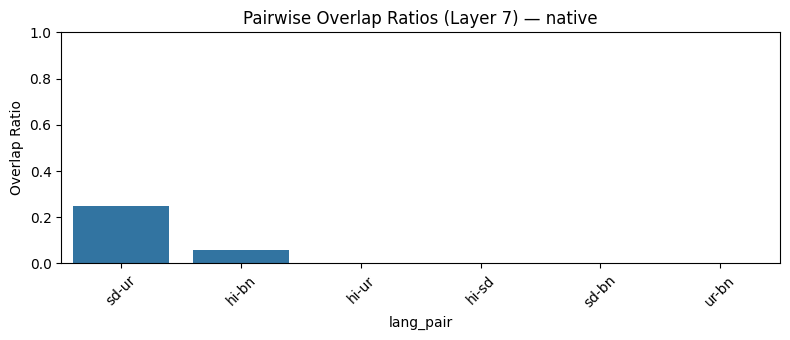

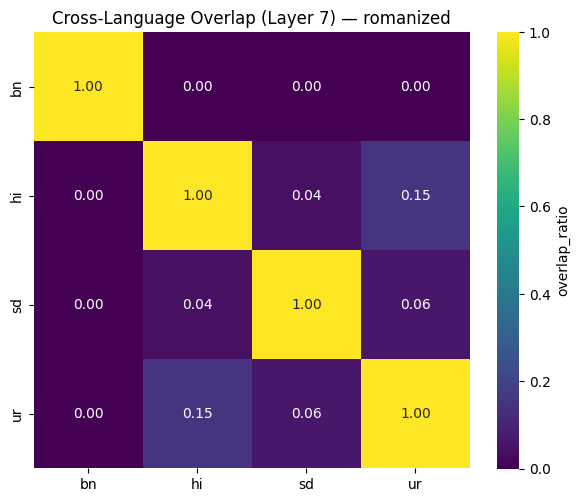

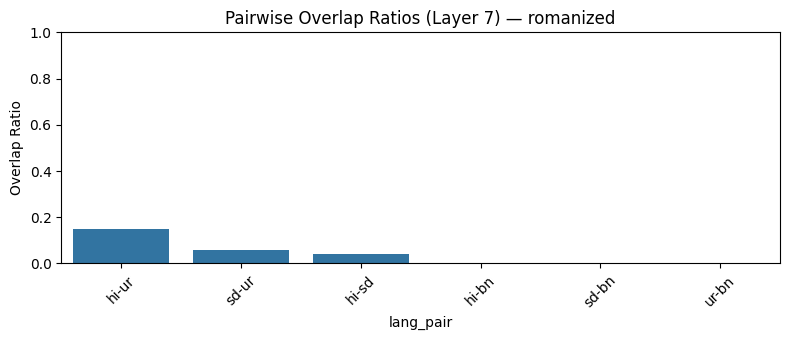

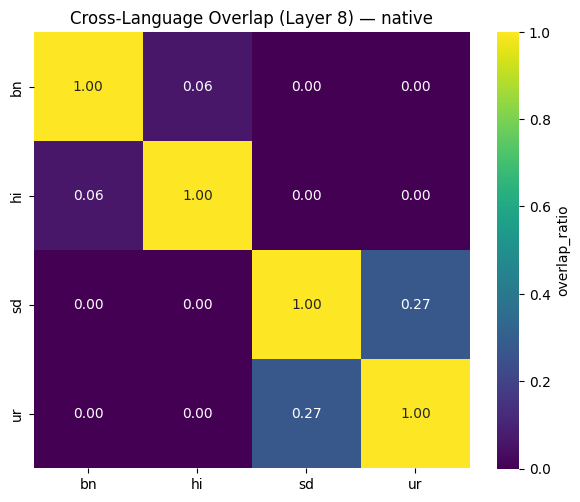

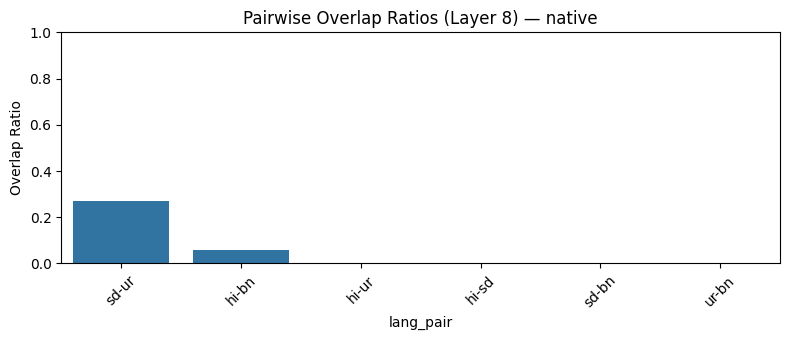

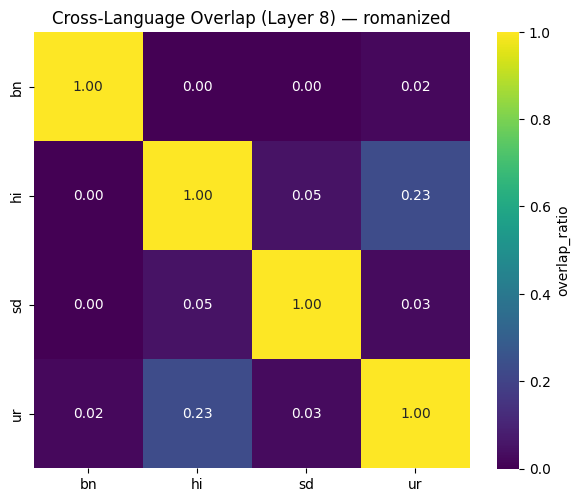

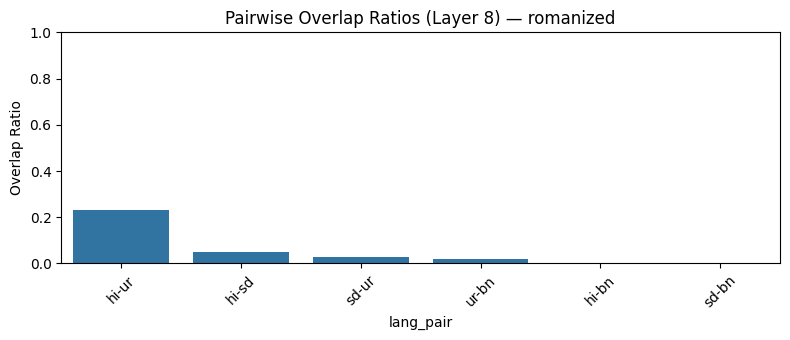

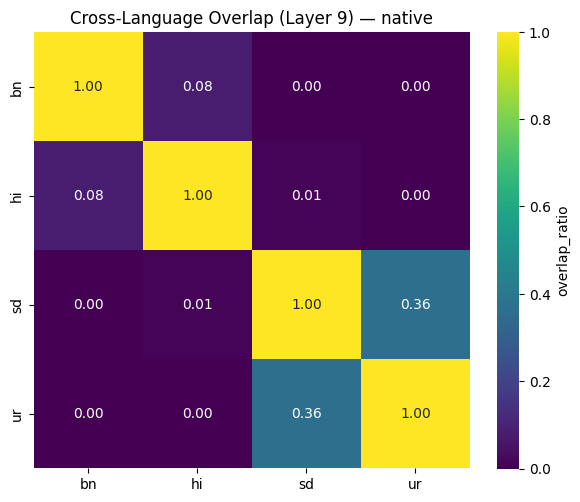

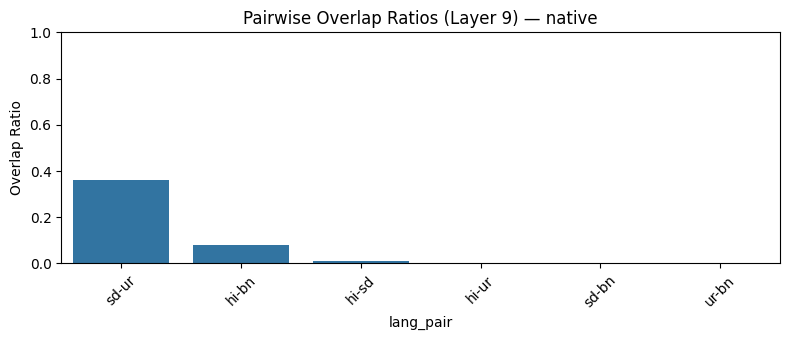

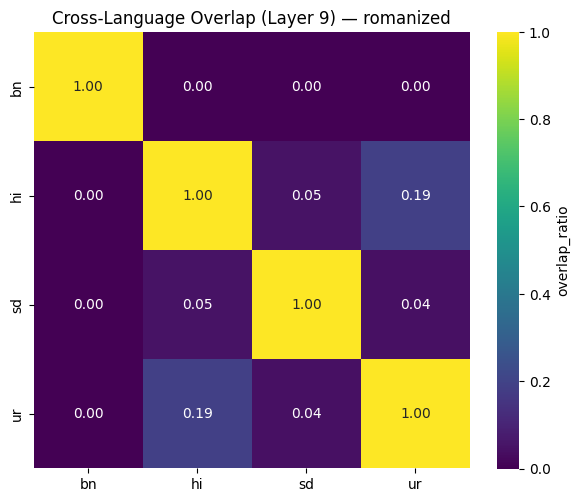

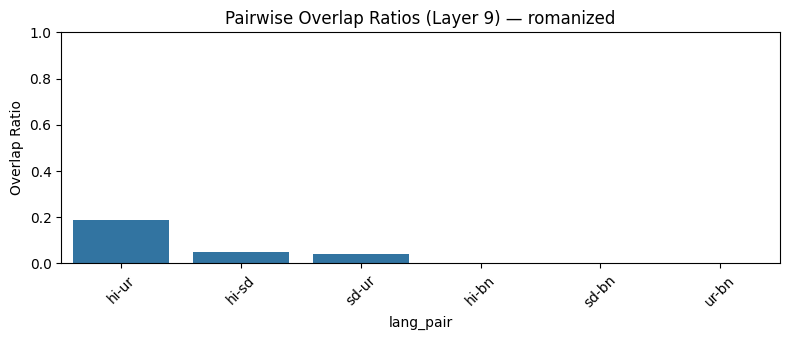

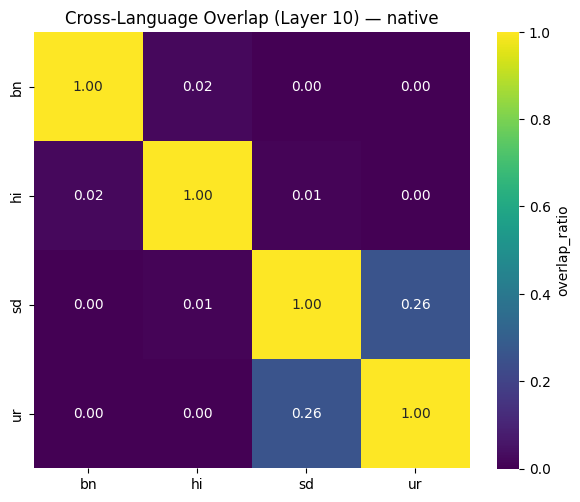

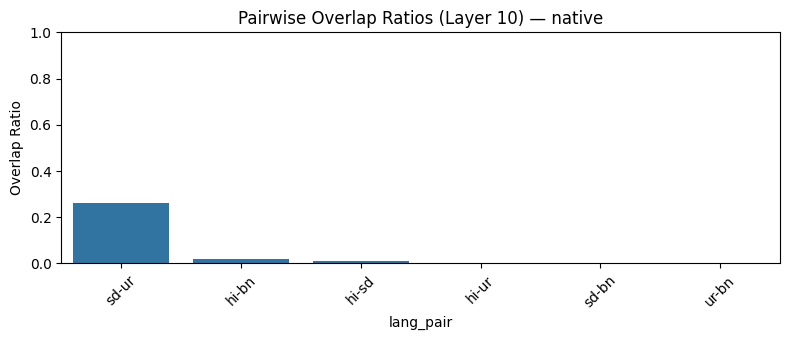

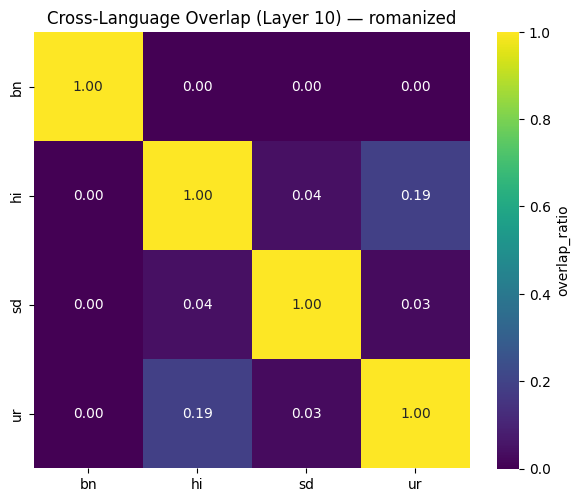

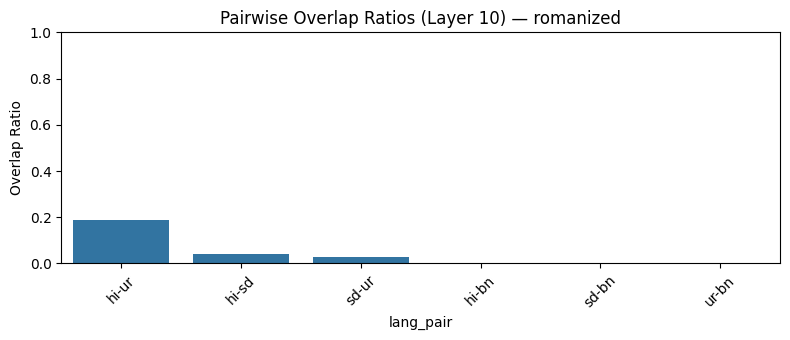

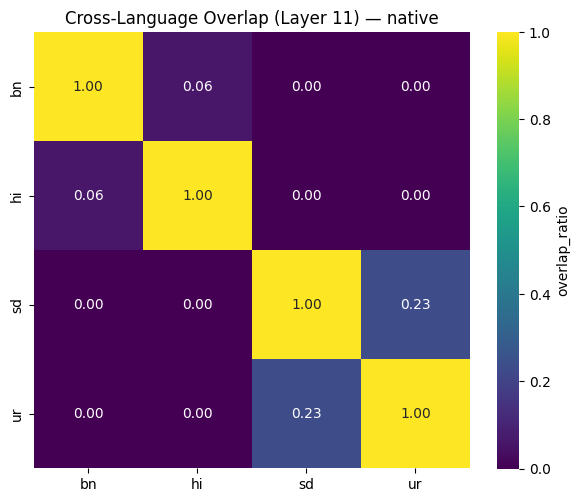

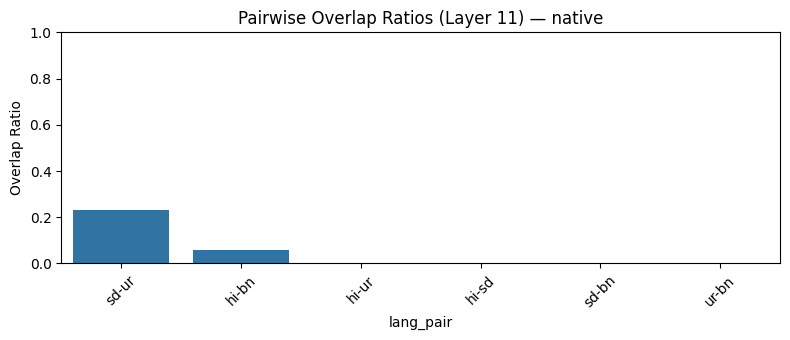

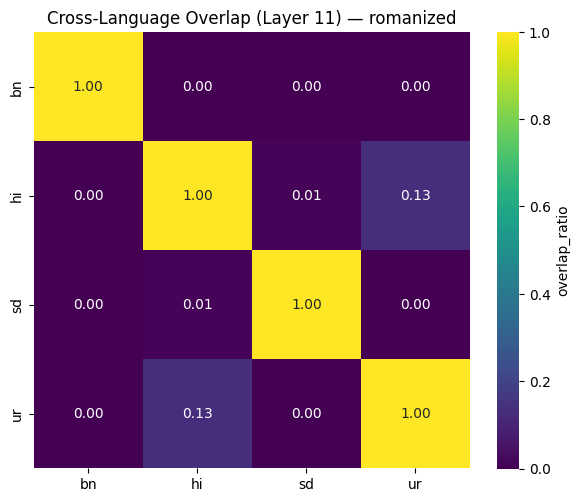

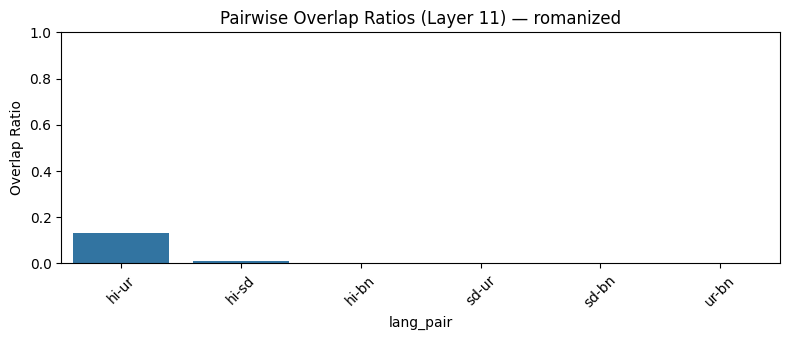

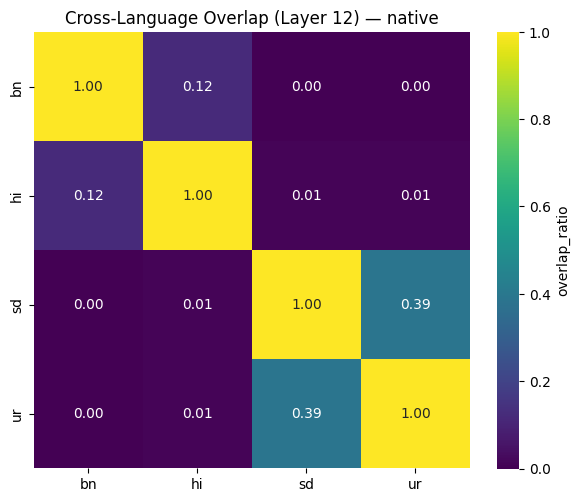

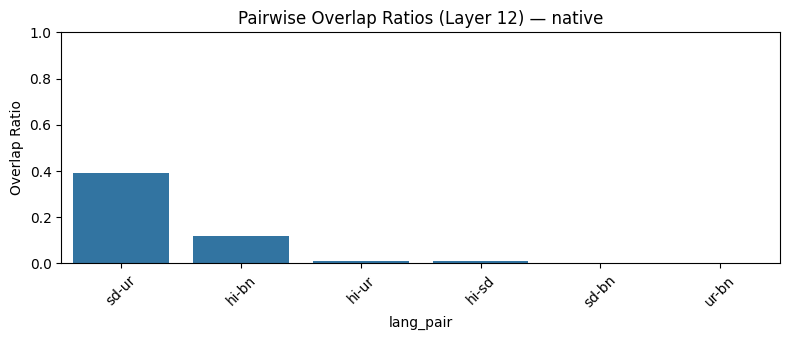

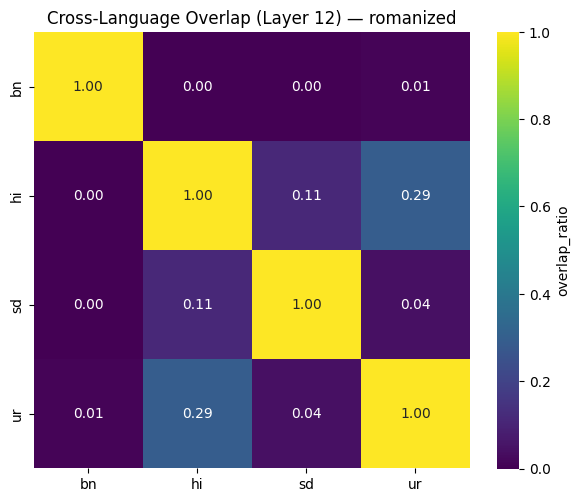

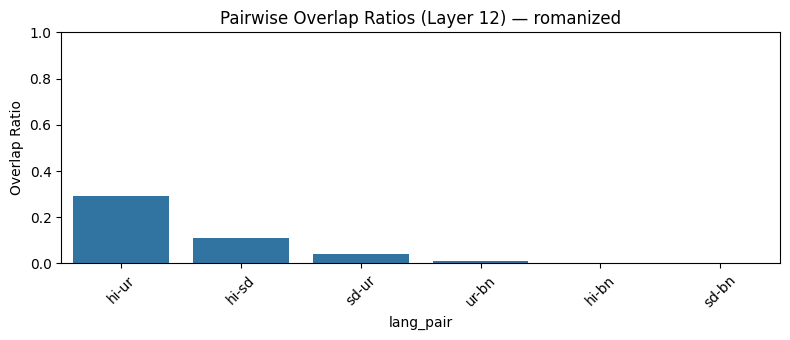

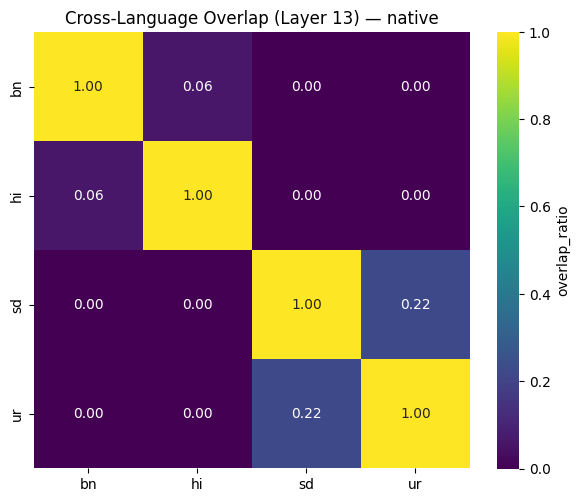

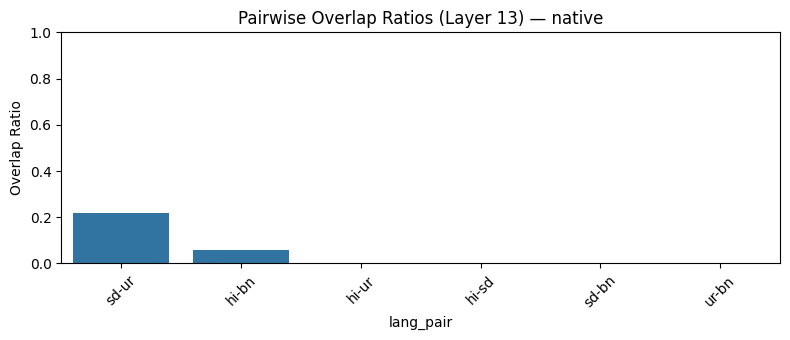

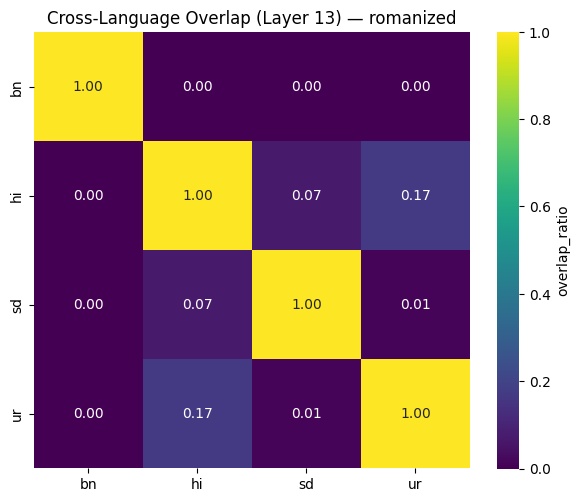

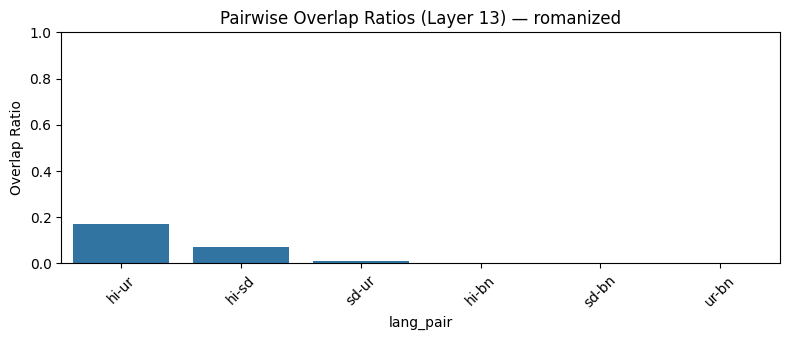

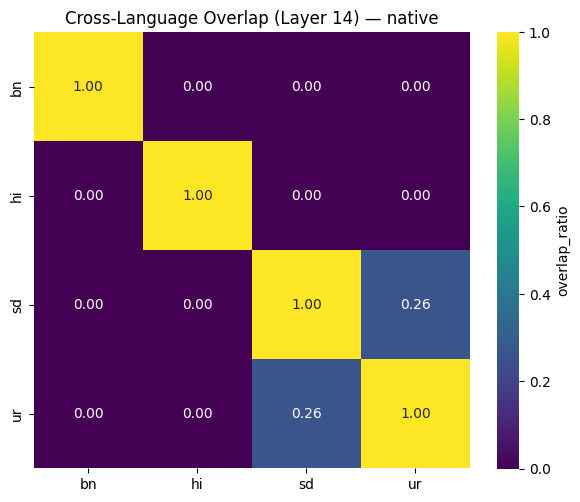

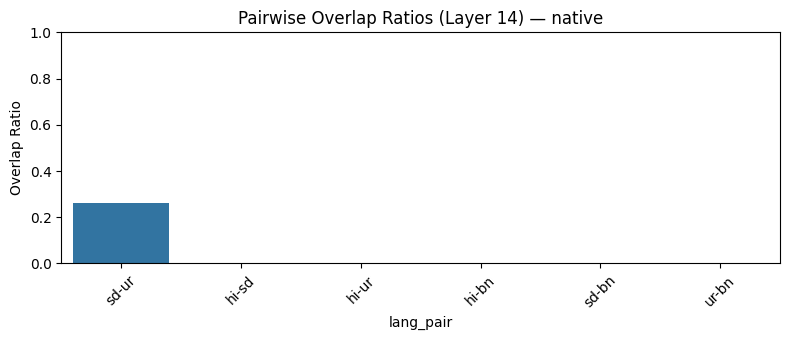

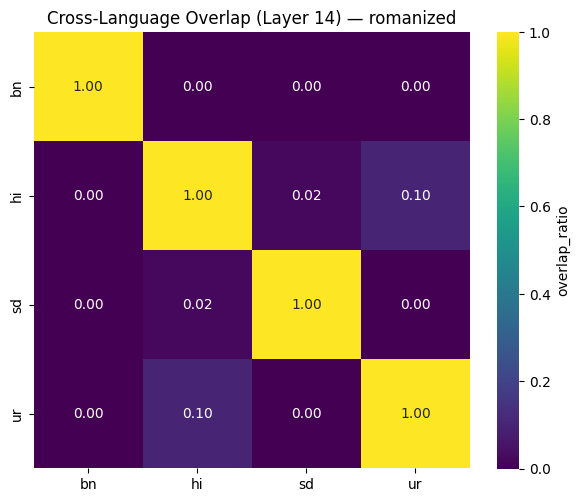

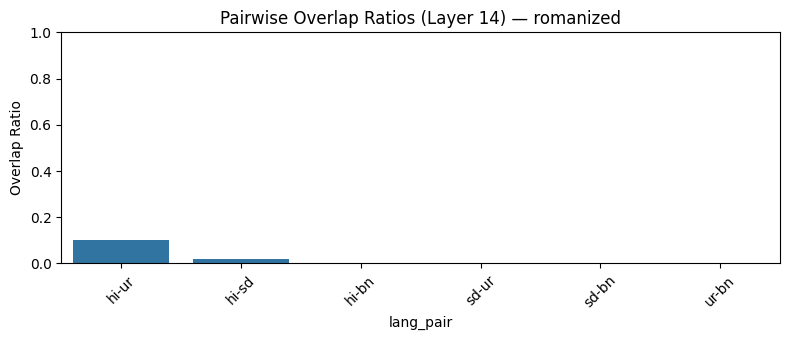

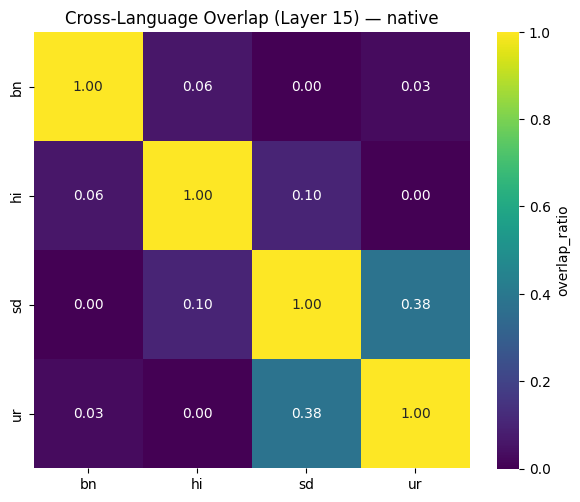

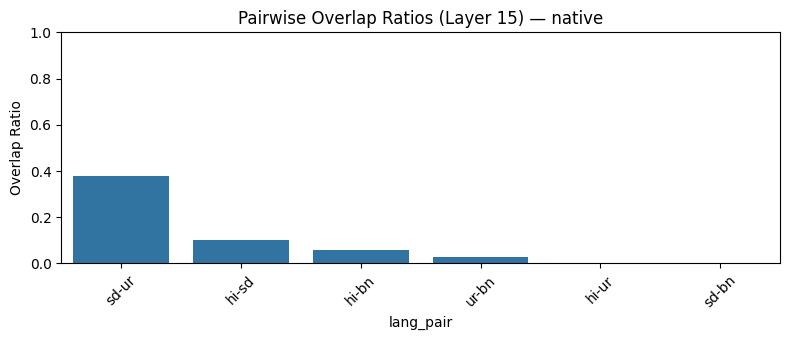

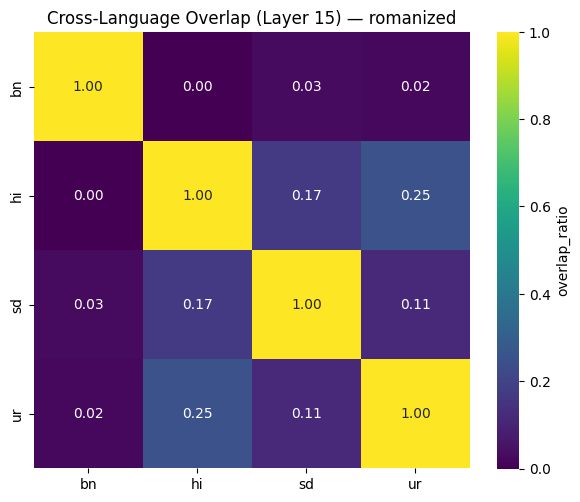

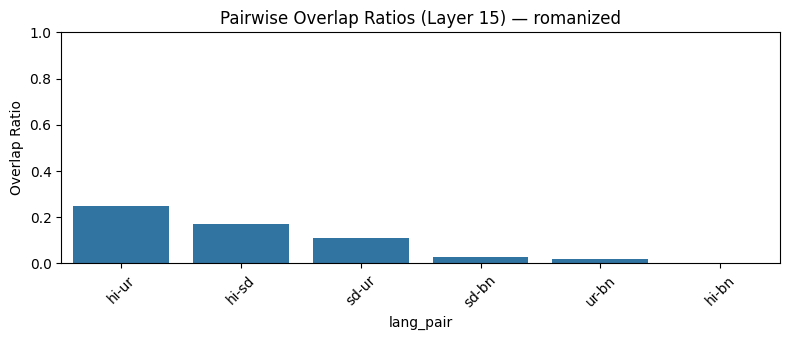

In [ ]:
# Corrected heatmap + barplot for cross-language overlap (per-layer)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# choose layer to visualize
for layer_to_visualize in range(16):

    # derive variants present and languages from df_cross
    variants = sorted(df_cross['variant'].unique())

    # derive language set by splitting lang_pair entries
    langs_set = set()
    for p in df_cross['lang_pair'].dropna().unique():
        parts = p.split('-')
        if len(parts) == 2:
            langs_set.update(parts)
    languages = sorted(langs_set)

    for variant in variants:
        # subset for chosen layer + variant
        subset = df_cross[(df_cross.layer == layer_to_visualize) & (df_cross.variant == variant)]
        if subset.empty:
            print(f"[WARN] No data for layer {layer_to_visualize}, variant {variant}")
            continue

        # create square matrix (languages x languages) filled with NaN
        mat = pd.DataFrame(np.nan, index=languages, columns=languages, dtype=float)

        # optionally set diagonal to 1.0 (a language fully overlaps with itself)
        for l in languages:
            mat.loc[l, l] = 1.0

        # fill symmetric cells from lang_pair values
        for _, row in subset.iterrows():
            pair = row['lang_pair']
            value = row['overlap_ratio']
            if isinstance(pair, str) and '-' in pair:
                a, b = pair.split('-')
                if a in mat.index and b in mat.columns:
                    mat.loc[a, b] = value
                    mat.loc[b, a] = value

        # if you prefer NaNs to show as blank, keep them; otherwise replace with 0 for plotting
        mat_plot = mat.fillna(0.0)

        # Heatmap
        plt.figure(figsize=(6,5))
        ax = sns.heatmap(
            mat_plot,
            annot=True,
            fmt=".2f",
            vmin=0.0,
            vmax=1.0,
            square=True,
            cmap="viridis",
            cbar_kws={'label': 'overlap_ratio'}
        )
        ax.set_title(f"Cross-Language Overlap (Layer {layer_to_visualize}) — {variant}")
        plt.tight_layout()
        plt.show()

        # Sorted barplot of language pairs
        pairs_df = subset.copy().dropna(subset=['lang_pair'])
        pairs_df = pairs_df.sort_values('overlap_ratio', ascending=False)

        plt.figure(figsize=(8,3.5))
        sns.barplot(x='lang_pair', y='overlap_ratio', data=pairs_df)
        plt.ylim(0, 1)
        plt.xticks(rotation=45)
        plt.title(f"Pairwise Overlap Ratios (Layer {layer_to_visualize}) — {variant}")
        plt.ylabel("Overlap Ratio")
        plt.tight_layout()
        plt.show()
